# 🌱 FarmTech Solutions — Modelagem de IA para Recomendação de Culturas Agrícolas

**Aluno:** Antuny Marques  
**RM:** 573852  
**Fase:** 3 | **Capítulo:** 10  
**Disciplina:** Inteligência Artificial — FIAP

---

## 📌 Objetivo do Projeto

Analisar uma base de dados com informações de condições de solo e clima, relacionadas ao tipo de produto agrícola plantado. O projeto é dividido em quatro grandes etapas:

1. **Análise Exploratória dos Dados (EDA)** — familiarização com o dataset e entendimento das variáveis.
2. **Análise Descritiva com Gráficos** — mínimo de 5 visualizações com narrativa analítica.
3. **Perfil Ideal de Solo e Clima** — identificação das condições ideais e comparação com 3 culturas selecionadas.
4. **Modelos Preditivos de Machine Learning** — desenvolvimento e avaliação de 5 modelos com algoritmos distintos.

---

## 📂 Dataset

O arquivo `produtos_agricolas.csv` contém as seguintes variáveis:

| Variável | Descrição |
|----------|-----------|
| `N` | Quantidade de Nitrogênio no solo |
| `P` | Quantidade de Fósforo no solo |
| `K` | Quantidade de Potássio no solo |
| `temperature` | Temperatura média da região (°C) |
| `humidity` | Umidade média do ar (%) |
| `ph` | pH do solo |
| `rainfall` | Precipitação pluviométrica (mm) |
| `label` | Tipo de cultura agrícola (variável alvo) |


---

## 📦 Etapa 1 — Preparação do Ambiente

Importação de todas as bibliotecas necessárias para análise de dados, visualização e Machine Learning.


In [1]:
import pandas as pd
import numpy as np # Biblioteca para dados

import matplotlib.pyplot as plt 
import seaborn as sns # Biblioteca para gráficos

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report # Biblioteca de Algoritmos para Machine Learning

import warnings
warnings.filterwarnings('ignore') 

print("Todas as bibliotecas foram importadas com sucesso!")


Todas as bibliotecas foram importadas com sucesso!


---

## 🔍 Etapa 2 — Carregamento e Exploração dos Dados

### 2.1 Carregamento e Primeiras Linhas

Carregamos o dataset e exibimos as primeiras linhas para ter uma visão inicial da estrutura dos dados.


In [2]:
# Carregue seu arquivo
df = pd.read_csv('produtos_agricolas.csv')

# Primeiras linhas
print(df.head())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


### 2.2 Informações Estruturais do Dataset

Verificamos as dimensões, tipos de dados, presença de valores nulos e as estatísticas descritivas de cada variável numérica.


In [3]:
# Dimensão do dataset
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

print("---------------------------------")

# Tipos de dados
print("\nTipos de dados:")
print(df.dtypes)

print("---------------------------------")

# Verificar valores faltantes
print(f"\n Valores faltantes: ")
print(df.isnull().sum())

print("---------------------------------")

#Estatísticas descritivas
print("\n Estatísticas descritivas: ")
print(df.describe())



Número de linhas: 2200
Número de colunas: 8
---------------------------------

Tipos de dados:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object
---------------------------------

 Valores faltantes: 
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
---------------------------------

 Estatísticas descritivas: 
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.26195

### 2.3 Distribuição das Culturas

Verificamos quantas culturas distintas existem no dataset e se a base está balanceada entre as classes.


In [4]:
print(f"Quantidade de culturas diferentes: {df['label'].nunique()}")
print(f"Quantidade de registro por cultura: {df['label'].value_counts()}")




Quantidade de culturas diferentes: 22
Quantidade de registro por cultura: label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


**Achado:** O dataset contém **22 culturas distintas**, com **100 registros por cultura**, totalizando 2.200 amostras. A distribuição perfeitamente uniforme é ideal para o treinamento de modelos de Machine Learning, pois elimina o problema de classes desbalanceadas.


---

## 📊 Etapa 3 — Análise Exploratória com Gráficos (EDA)

Nesta etapa, utilizamos 11 visualizações para explorar o comportamento das variáveis e identificar padrões relevantes. Cada gráfico é seguido de uma análise textual dos principais achados.


### 3.1 Gráfico 1 — Distribuição de Produtos Agrícolas no Dataset

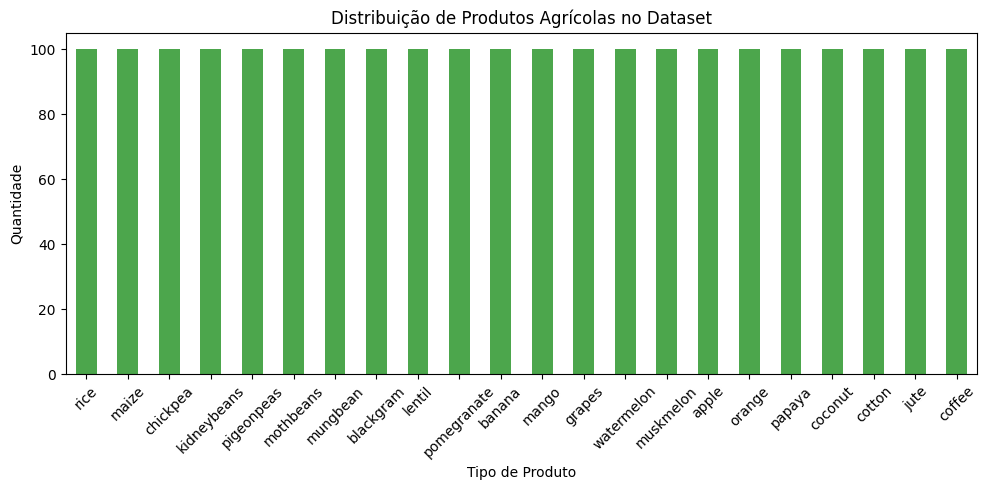

In [5]:
plt.figure(figsize=(10, 5))
df['label'].value_counts().plot(kind='bar', color='green', alpha=0.7)
plt.title('Distribuição de Produtos Agrícolas no Dataset')
plt.xlabel('Tipo de Produto')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Análise:** A base de dados é perfeitamente balanceada, com exatamente 100 registros para cada um dos 22 tipos de cultura. Essa distribuição uniforme é extremamente benéfica para o treinamento de modelos preditivos, pois evita que o algoritmo desenvolva viés para classes mais frequentes.


### 3.2 Gráfico 2 — Distribuição da Temperatura

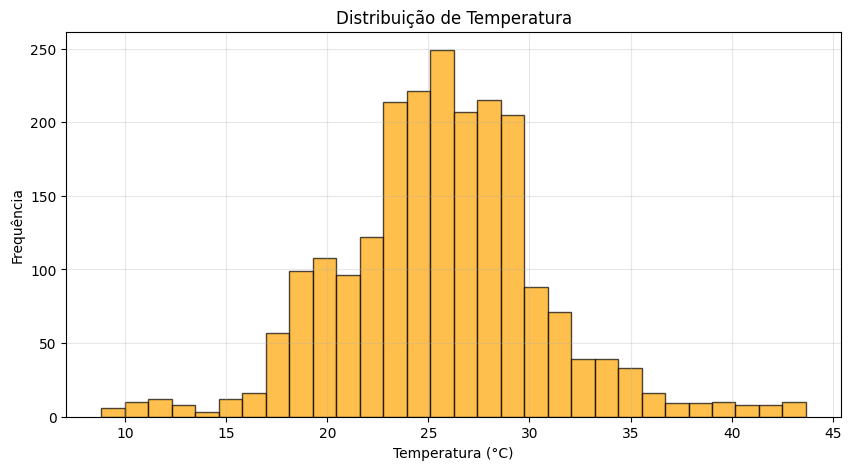

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(df['temperature'], bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.title('Distribuição de Temperatura')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)
plt.show()

**Análise:** A distribuição de temperatura apresenta formato aproximadamente normal, com concentração de amostras entre 20°C e 30°C. O pico ocorre próximo de 25°C, caracterizando um clima predominantemente tropical e subtropical. Temperaturas extremas (abaixo de 10°C ou acima de 42°C) são raras, indicando que o dataset representa regiões de clima ameno a quente.


### 3.3 Gráfico 3 — Matriz de Correlação entre Variáveis

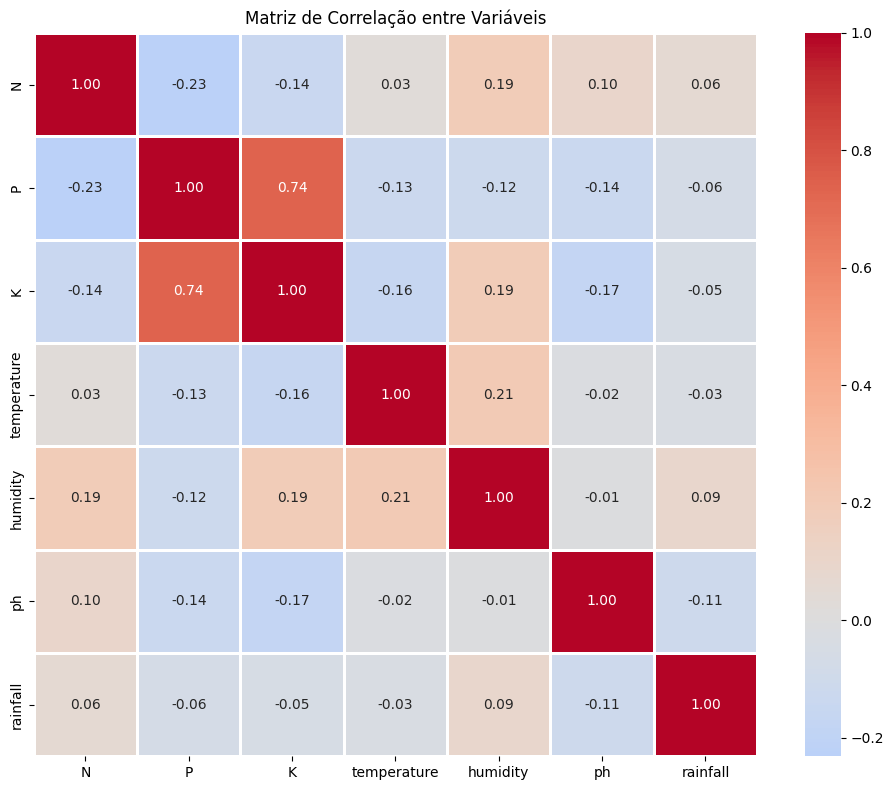

In [7]:
# Matriz de correlação
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Matriz de Correlação entre Variáveis')
plt.tight_layout()
plt.show()

**Análise:** O mapa de calor revela uma **correlação positiva muito forte entre Fósforo (P) e Potássio (K)** (próxima de 1.0), sugerindo que culturas com alta demanda de um nutriente também exigem o outro. As demais variáveis apresentam correlações fracas entre si, o que é positivo: significa que cada variável contribui com informação independente para os modelos preditivos.


### 3.4 Gráfico 4 — Box Plot: Temperatura por Tipo de Cultura

<Figure size 1600x600 with 0 Axes>

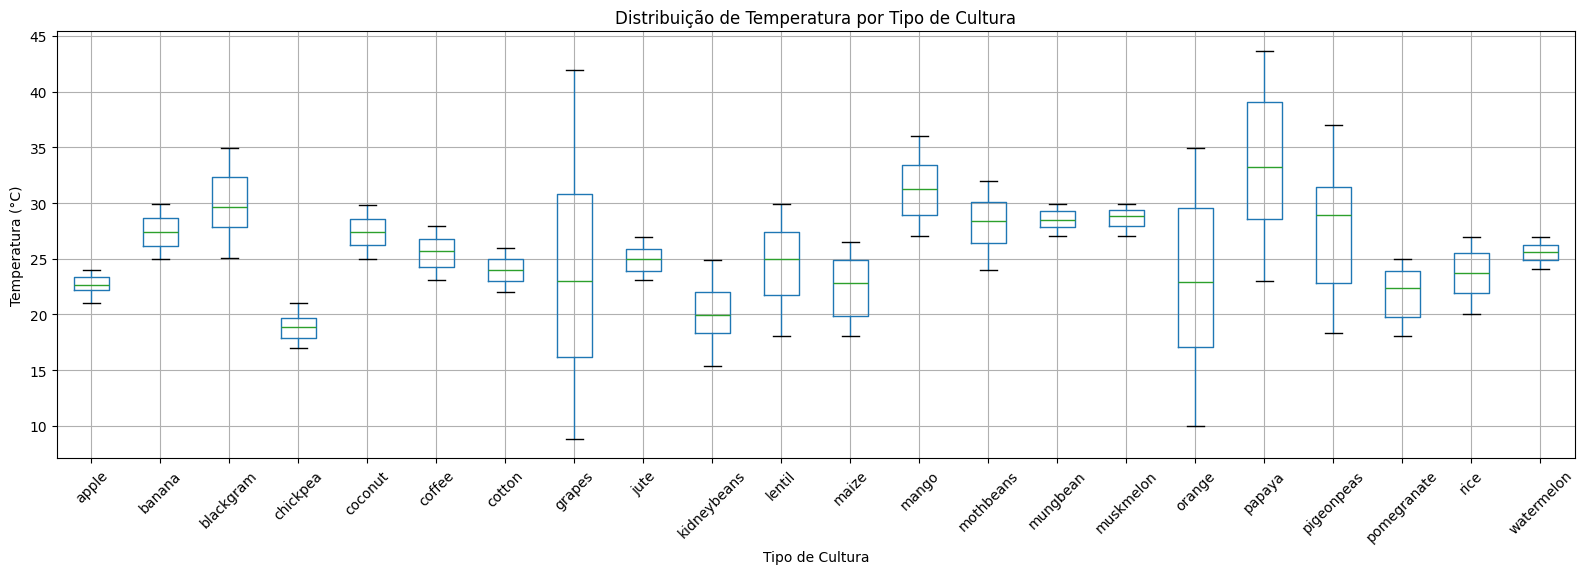

In [8]:
plt.figure(figsize=(16, 6))
df.boxplot(column='temperature', by='label', figsize=(16, 6))
plt.title('Distribuição de Temperatura por Tipo de Cultura')
plt.suptitle('')  # Remove o título automático feio
plt.xlabel('Tipo de Cultura')
plt.ylabel('Temperatura (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Análise:** Existem diferenças expressivas na faixa de temperatura preferida por cada cultura. Culturas como o **mamão (papaya)** exigem temperaturas elevadas e consistentes (baixa variância). Já **uvas (grapes)** prosperam em temperaturas consideravelmente mais baixas. Essa variabilidade confirma que a temperatura é uma variável discriminante importante para os modelos.


### 3.5 Gráfico 5 — Box Plot: Umidade por Tipo de Cultura

<Figure size 1600x600 with 0 Axes>

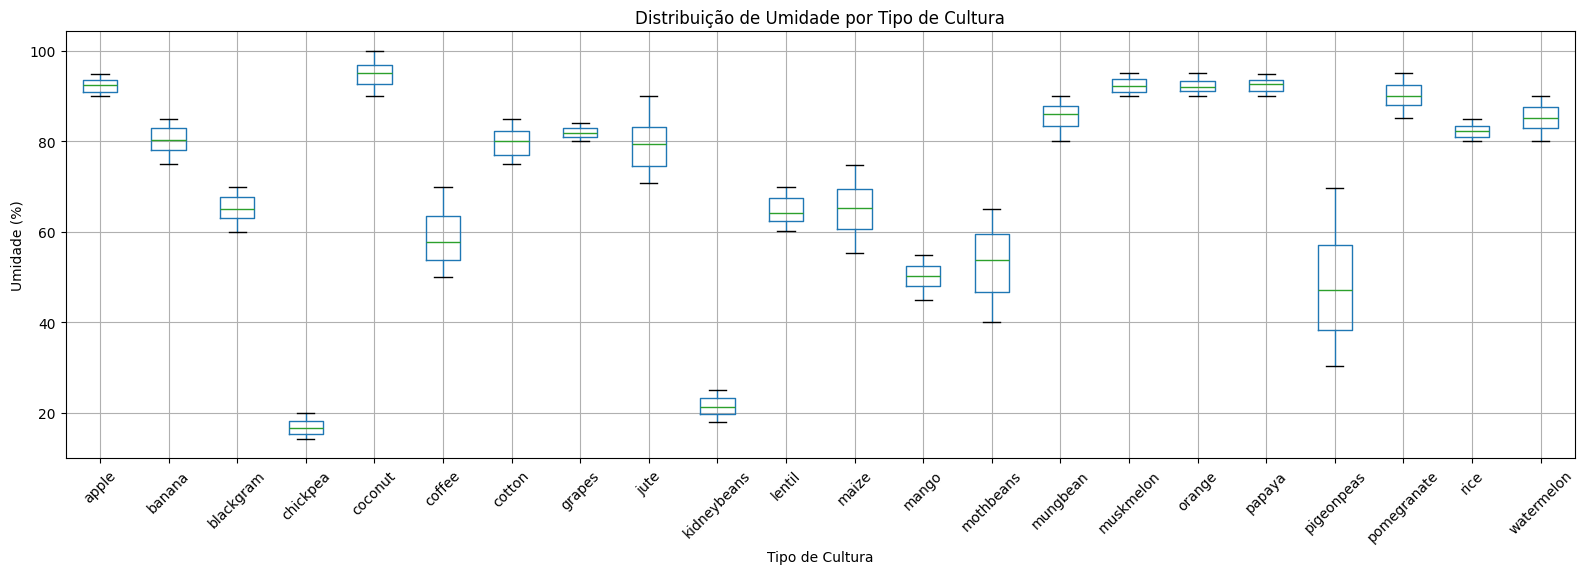

In [9]:
plt.figure(figsize=(16, 6))
df.boxplot(column='humidity', by='label', figsize=(16, 6))
plt.title('Distribuição de Umidade por Tipo de Cultura')
plt.suptitle('')
plt.xlabel('Tipo de Cultura')
plt.ylabel('Umidade (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Análise:** A umidade é um dos fatores de maior poder discriminante entre as culturas. Algumas delas, como a **cana-de-açúcar (sugarcane)**, exigem umidade acima de 80%, enquanto outras, como o **grão-de-bico (chickpea)**, prosperam em ambientes muito secos. A amplitude das caixas indica que certas culturas toleram variações amplas, enquanto outras são extremamente sensíveis.


### 3.6 Gráfico 6 — Box Plot: Precipitação por Tipo de Cultura

<Figure size 1600x600 with 0 Axes>

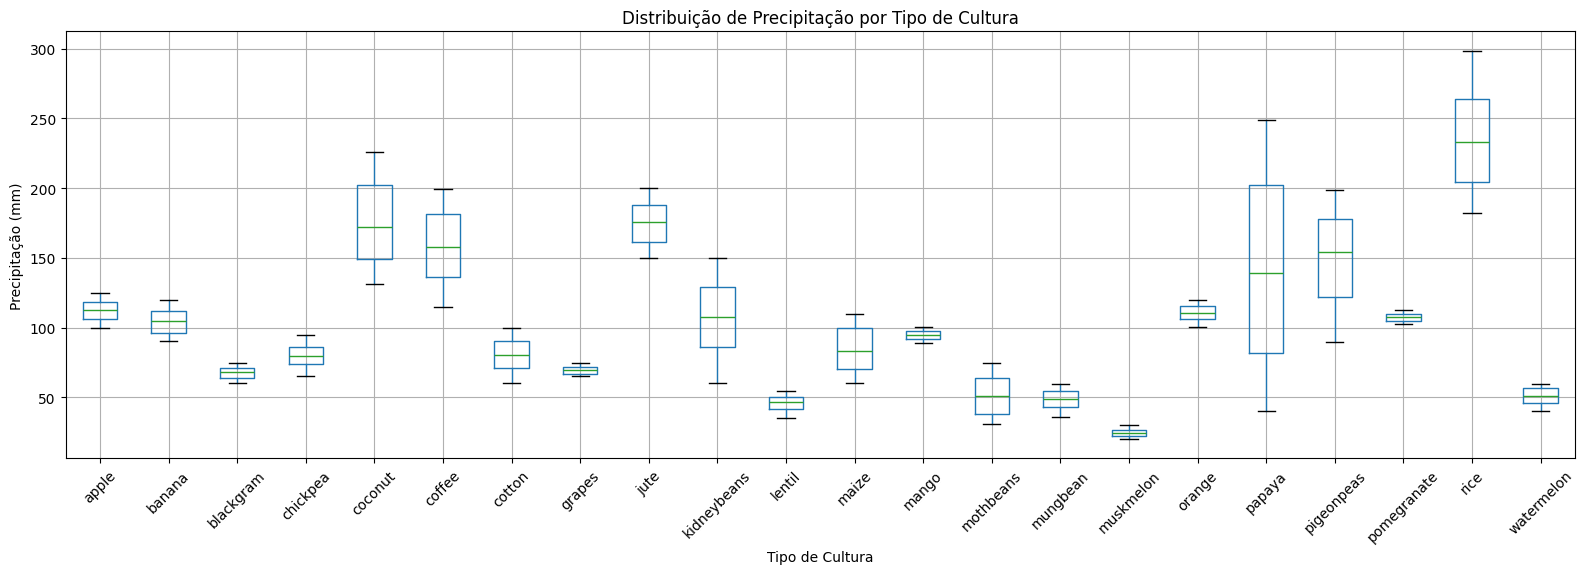

In [10]:
plt.figure(figsize=(16, 6))
df.boxplot(column='rainfall', by='label', figsize=(16, 6))
plt.title('Distribuição de Precipitação por Tipo de Cultura')
plt.suptitle('')
plt.xlabel('Tipo de Cultura')
plt.ylabel('Precipitação (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Análise:** A precipitação separa claramente dois grupos: culturas aquáticas ou tropicais com alta demanda hídrica, como o **arroz (rice)**, que apresenta os maiores valores e maior dispersão; e culturas de clima seco, como o **melão (muskmelon)**, com precipitação muito baixa. Essa variável é um forte preditor para distinguir culturas extremas.


### 3.7 Gráfico 7 — Heatmap: Nutrientes Médios (N, P, K) por Cultura

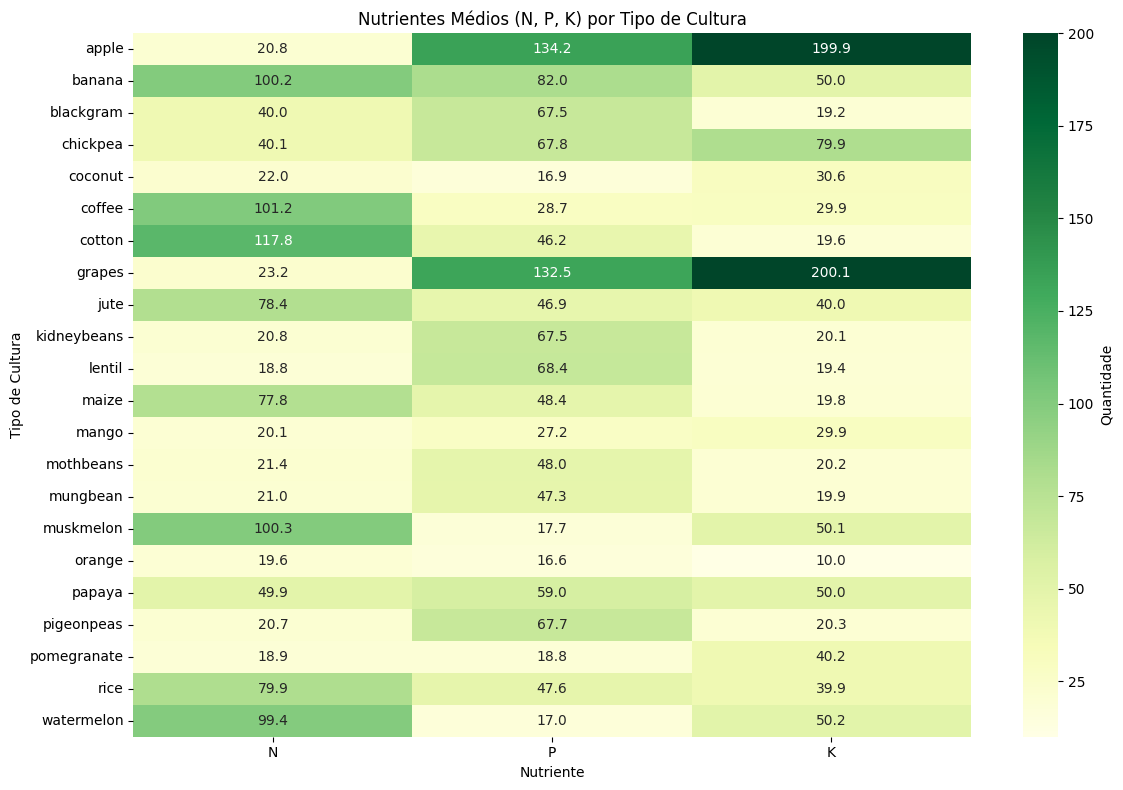

In [11]:
# Calcular média de nutrientes por cultura
nutrientes_por_cultura = df.groupby('label')[['N', 'P', 'K']].mean()

plt.figure(figsize=(12, 8))
sns.heatmap(nutrientes_por_cultura, annot=True, fmt='.1f', cmap='YlGn', cbar_kws={'label': 'Quantidade'})
plt.title('Nutrientes Médios (N, P, K) por Tipo de Cultura')
plt.xlabel('Nutriente')
plt.ylabel('Tipo de Cultura')
plt.tight_layout()
plt.show()

**Análise:** As necessidades nutricionais variam drasticamente entre as culturas. O **algodão (cotton)** apresenta a maior demanda de Nitrogênio (N). Já **maçã (apple)** e **uva (grapes)** dependem intensamente de Fósforo (P) e Potássio (K), o que explica a alta correlação P-K identificada anteriormente. Culturas como o **arroz (rice)** e o **milho (maize)** apresentam demandas mais equilibradas dos três nutrientes.


### 3.8 Gráfico 8 — Scatter: Temperatura vs. Precipitação (3 Culturas Selecionadas)

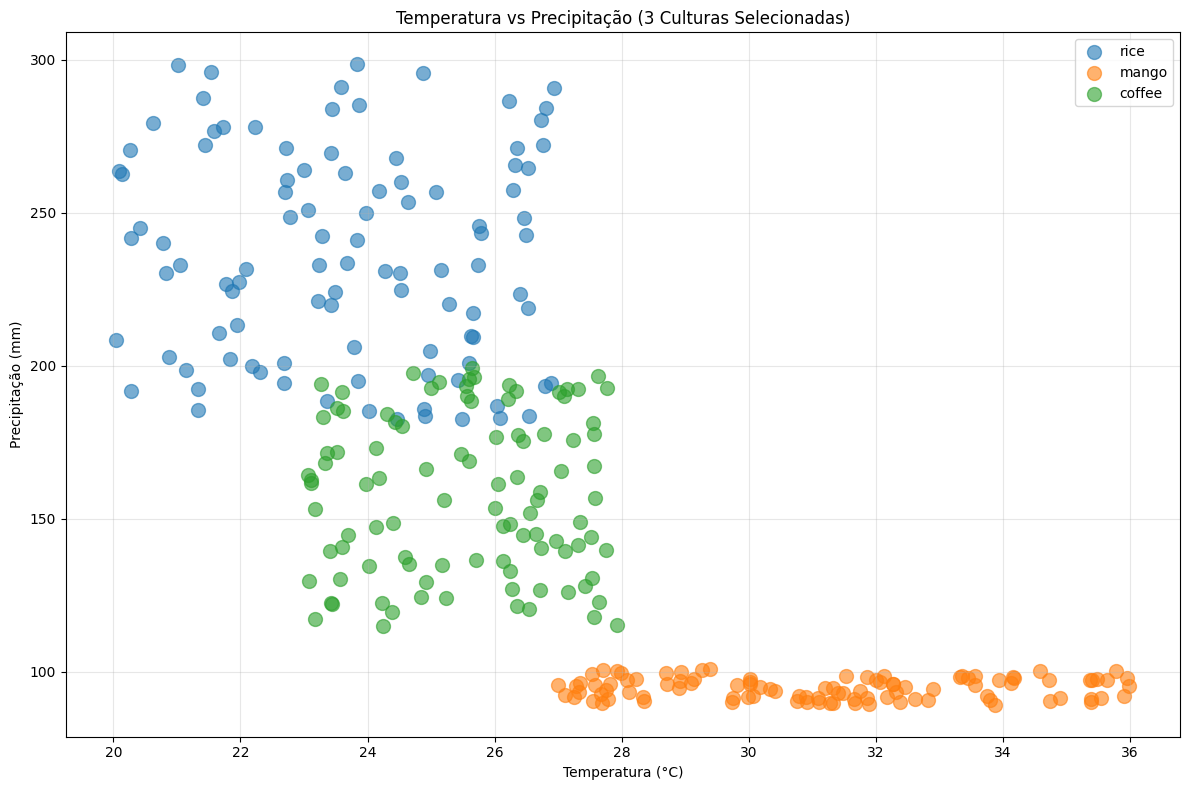

In [12]:
plt.figure(figsize=(12, 8))

# Usando apenas 3 culturas
culturas_destaque = ['rice', 'mango', 'coffee']  

for cultura in culturas_destaque:
    dados_cultura = df[df['label'] == cultura]
    plt.scatter(dados_cultura['temperature'], dados_cultura['rainfall'], 
               label=cultura, alpha=0.6, s=100)

plt.title('Temperatura vs Precipitação (3 Culturas Selecionadas)')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Precipitação (mm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Análise:** O gráfico de dispersão evidencia a separação entre as três culturas analisadas. O **arroz (rice)** destaca-se pelo cluster de alta precipitação, claramente separado das outras. O **café (coffee)** e a **manga (mango)** compartilham faixas similares de temperatura, mas se diferenciam levemente em precipitação. Isso indica que variáveis adicionais (como solo e nutrientes) são necessárias para distingui-los completamente.


### 3.9 Gráfico 9 — Box Plot: pH do Solo por Tipo de Cultura

<Figure size 1600x600 with 0 Axes>

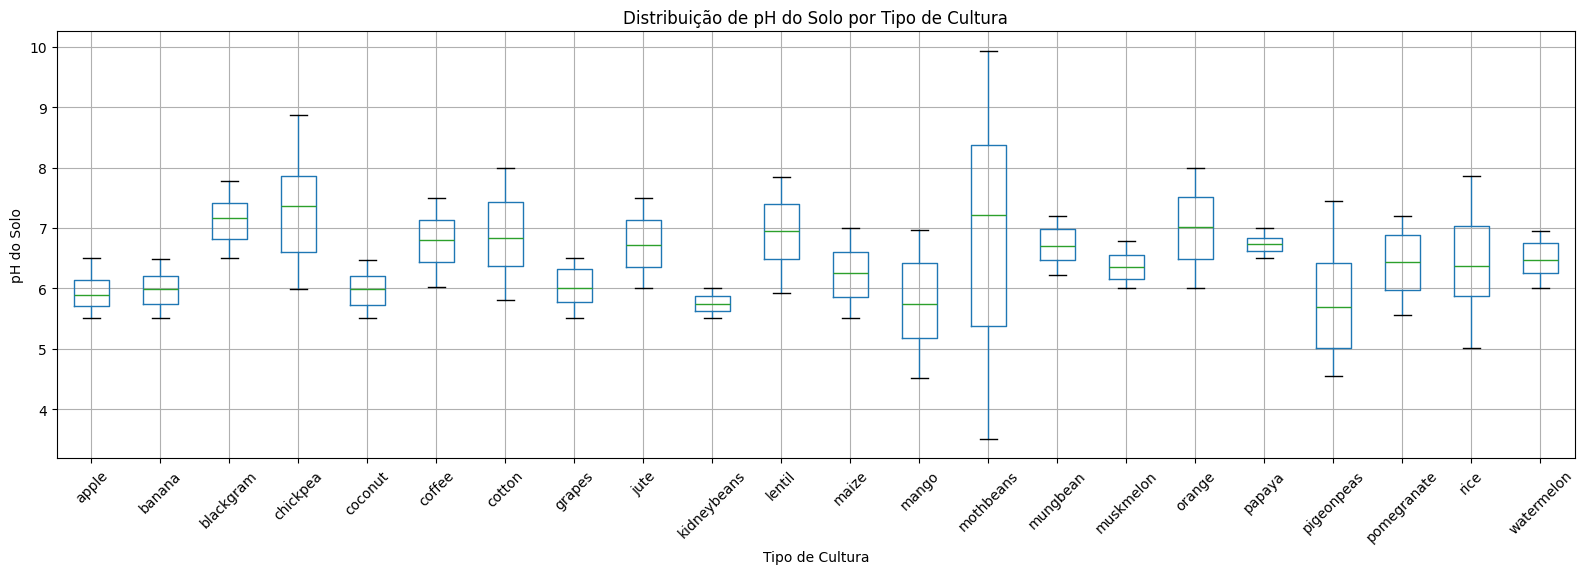

In [13]:
plt.figure(figsize=(16, 6))
df.boxplot(column='ph', by='label', figsize=(16, 6))
plt.title('Distribuição de pH do Solo por Tipo de Cultura')
plt.suptitle('')
plt.xlabel('Tipo de Cultura')
plt.ylabel('pH do Solo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Análise:** A maioria das culturas prefere solos com pH entre **6.0 e 7.0** (levemente ácido a neutro), que é a faixa ideal para absorção de nutrientes. Algumas culturas, como **arroz (rice)** e **juta (jute)**, toleram solos mais ácidos (pH abaixo de 6), enquanto **algodão (cotton)** e **grão-de-bico (chickpea)** preferem solos ligeiramente mais alcalinos.


### 3.10 Gráfico 10 — Scatter: Fósforo (P) vs. Potássio (K) por Cultura

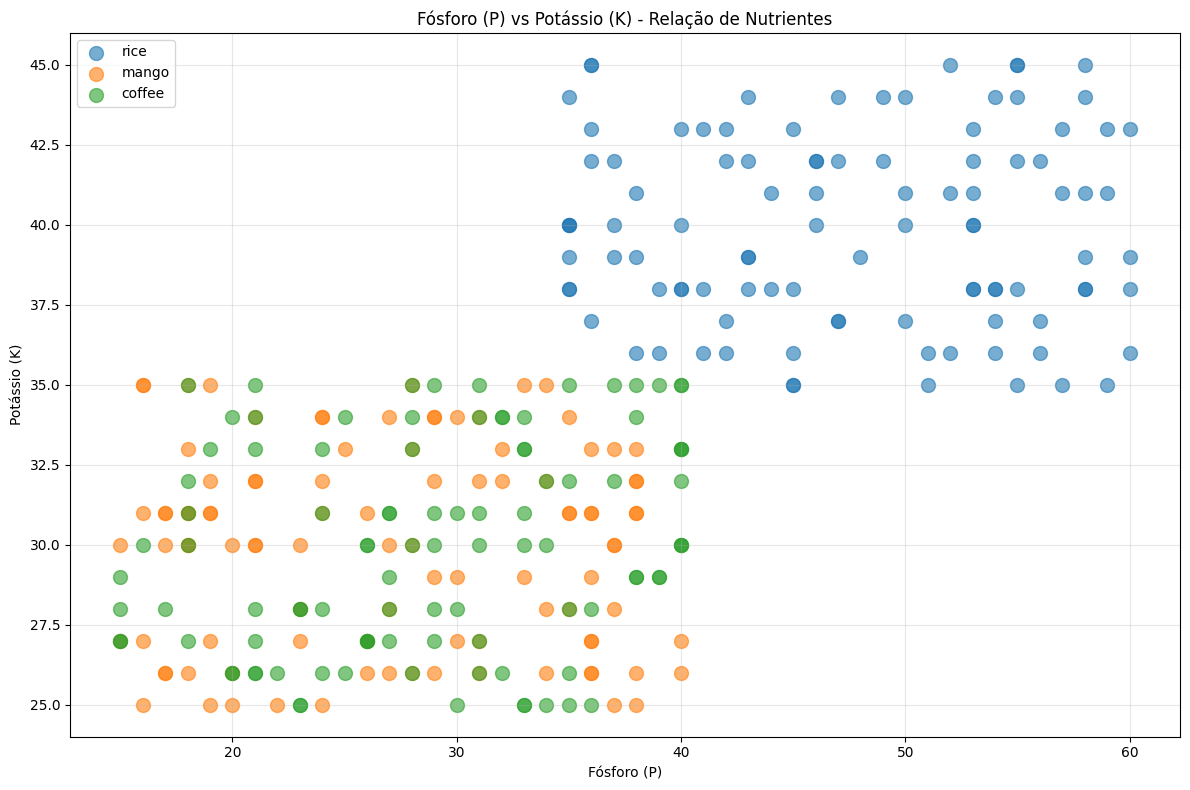

In [14]:
plt.figure(figsize=(12, 8))

culturas_destaque = ['rice', 'mango', 'coffee']
for cultura in culturas_destaque:
    dados_cultura = df[df['label'] == cultura]
    plt.scatter(dados_cultura['P'], dados_cultura['K'], 
               label=cultura, alpha=0.6, s=100)

plt.title('Fósforo (P) vs Potássio (K) - Relação de Nutrientes')
plt.xlabel('Fósforo (P)')
plt.ylabel('Potássio (K)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Análise:** A correlação linear positiva entre P e K é nitidamente visível neste gráfico. Para as três culturas analisadas (arroz, manga e café), os valores de ambos os nutrientes ficam concentrados abaixo de 50, indicando que são culturas de demanda nutricional moderada em comparação com culturas como maçã e uva, que ocupariam quadrantes superiores.


### 3.11 Gráfico 11 — Distribuição de Todas as Variáveis Numéricas

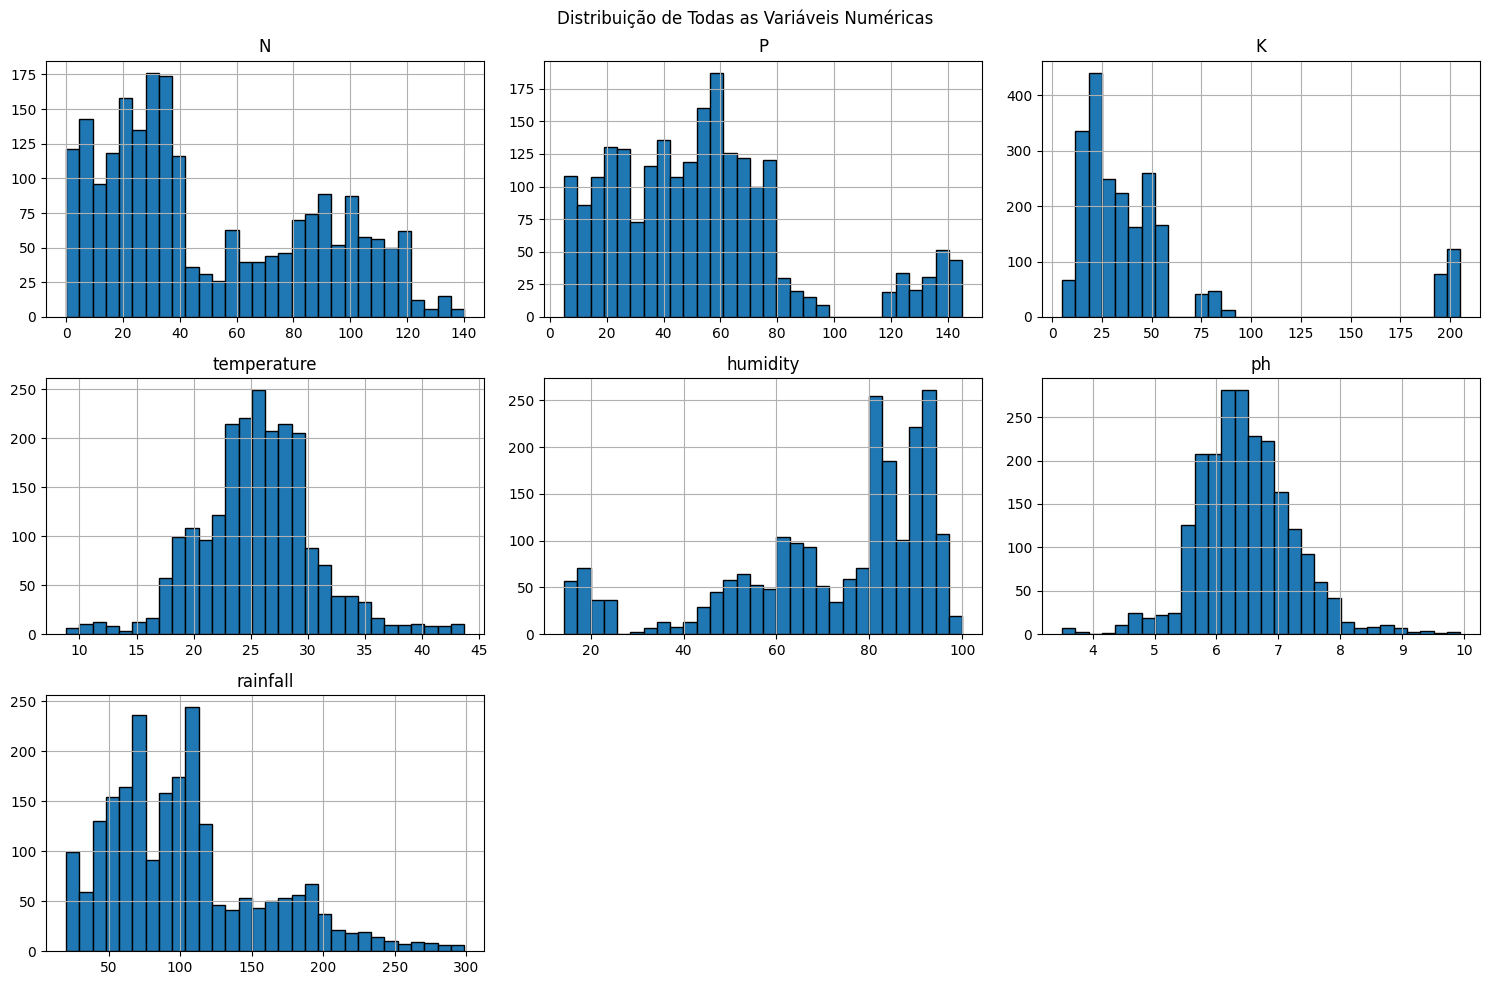

In [15]:
df.hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.suptitle('Distribuição de Todas as Variáveis Numéricas')
plt.tight_layout()
plt.show()

**Análise:** Os histogramas consolidados revelam o comportamento geral do dataset. As variáveis **pH** e **temperatura** seguem distribuições aproximadamente normais (formato de sino), facilitando a modelagem. Já a **precipitação (rainfall)** apresenta forte assimetria à direita, puxada pelas culturas de alta demanda hídrica. **N, P e K** mostram distribuições mais irregulares, refletindo a grande heterogeneidade de necessidades nutricionais entre as 22 culturas.


---

## 🌾 Etapa 4 — Perfil Ideal de Solo e Clima: Comparação entre Culturas

Nesta etapa, identificamos o **perfil médio ideal** de solo e clima — calculado a partir de todas as culturas do dataset — e o comparamos com três culturas escolhidas: **Arroz (rice)**, **Manga (mango)** e **Café (coffee)**. A análise combina estatística descritiva, testes de hipótese (ANOVA) e visualizações comparativas.


### 4.1 Culturas Disponíveis no Dataset

In [16]:
print(df['label'].unique())

<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str


### 4.2 Perfil Médio das Três Culturas Selecionadas

In [17]:
# IMPORTANTE: Substitua 'rice', 'mango', 'coffee' pelas suas 3 escolhas
culturas_analise = ['rice', 'mango', 'coffee']

# Calcule os valores médios para cada cultura
perfis = df[df['label'].isin(culturas_analise)].groupby('label').agg({
    'N': 'mean',
    'P': 'mean',
    'K': 'mean',
    'temperature': 'mean',
    'humidity': 'mean',
    'ph': 'mean',
    'rainfall': 'mean'
}).round(2)

print("📊 PERFIL MÉDIO DE CADA CULTURA:")
print(perfis)

📊 PERFIL MÉDIO DE CADA CULTURA:
             N      P      K  temperature  humidity    ph  rainfall
label                                                              
coffee  101.20  28.74  29.94        25.54     58.87  6.79    158.07
mango    20.07  27.18  29.92        31.21     50.16  5.77     94.70
rice     79.89  47.58  39.87        23.69     82.27  6.43    236.18


### 4.3 Perfil Ideal Geral (Média de Todas as Culturas)

In [18]:
perfil_ideal_geral = df.agg({
    'N': 'mean',
    'P': 'mean',
    'K': 'mean',
    'temperature': 'mean',
    'humidity': 'mean',
    'ph': 'mean',
    'rainfall': 'mean'
}).round(2)

print("🌍 PERFIL IDEAL GERAL (Média de todas as culturas):")
print(perfil_ideal_geral)

🌍 PERFIL IDEAL GERAL (Média de todas as culturas):
N               50.55
P               53.36
K               48.15
temperature     25.62
humidity        71.48
ph               6.47
rainfall       103.46
dtype: float64


### 4.4 Comparação Direta: Culturas vs. Perfil Ideal

In [19]:
# Criar um dataframe para comparação
comparacao = perfis.copy()
comparacao.loc['Ideal Geral'] = perfil_ideal_geral

print("\n🔍 COMPARAÇÃO: Suas 3 Culturas vs Ideal Geral")
print(comparacao)

# Calcular a diferença em relação ao ideal
print("\n📍 DIFERENÇA EM RELAÇÃO AO IDEAL (+ = acima da média, - = abaixo da média):")
diferenca = perfis.subtract(perfil_ideal_geral)
print(diferenca.round(2))


🔍 COMPARAÇÃO: Suas 3 Culturas vs Ideal Geral
                  N      P      K  temperature  humidity    ph  rainfall
label                                                                   
coffee       101.20  28.74  29.94        25.54     58.87  6.79    158.07
mango         20.07  27.18  29.92        31.21     50.16  5.77     94.70
rice          79.89  47.58  39.87        23.69     82.27  6.43    236.18
Ideal Geral   50.55  53.36  48.15        25.62     71.48  6.47    103.46

📍 DIFERENÇA EM RELAÇÃO AO IDEAL (+ = acima da média, - = abaixo da média):
            N      P      K  temperature  humidity    ph  rainfall
label                                                             
coffee  50.65 -24.62 -18.21        -0.08    -12.61  0.32     54.61
mango  -30.48 -26.18 -18.23         5.59    -21.32 -0.70     -8.76
rice    29.34  -5.78  -8.28        -1.93     10.79 -0.04    132.72


### 4.5 Visualização em Radar Chart

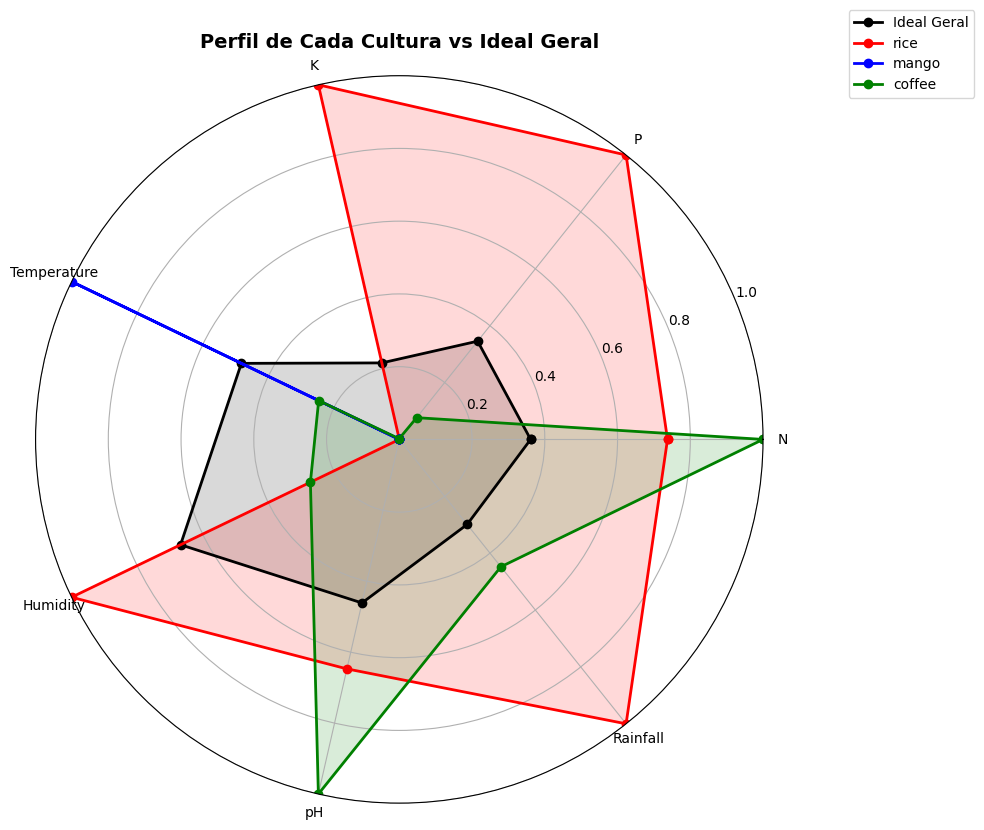

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Preparar dados
categorias = ['N', 'P', 'K', 'Temperature', 'Humidity', 'pH', 'Rainfall']
valores_ideal = perfil_ideal_geral.values

# Normalizar dados (0-1) para melhor visualização
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
perfis_norm = pd.DataFrame(
    scaler.fit_transform(perfis),
    index=perfis.index,
    columns=perfis.columns
)
ideal_norm = perfil_ideal_geral.copy()
for col in ideal_norm.index:
    ideal_norm[col] = (perfil_ideal_geral[col] - df[col].min()) / (df[col].max() - df[col].min())

# Criar radar chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

angles = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
angles += angles[:1]  # Fechar o gráfico

# Plotar ideal
valores_ideal_norm = ideal_norm.values.tolist()
valores_ideal_norm += valores_ideal_norm[:1]
ax.plot(angles, valores_ideal_norm, 'o-', linewidth=2, label='Ideal Geral', color='black')
ax.fill(angles, valores_ideal_norm, alpha=0.15, color='black')

# Plotar cada cultura
cores = ['red', 'blue', 'green']
for idx, (cultura, cor) in enumerate(zip(culturas_analise, cores)):
    valores = perfis_norm.loc[cultura].values.tolist()
    valores += valores[:1]
    ax.plot(angles, valores, 'o-', linewidth=2, label=cultura, color=cor)
    ax.fill(angles, valores, alpha=0.15, color=cor)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categorias)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('Perfil de Cada Cultura vs Ideal Geral', size=14, weight='bold', pad=20)
ax.grid(True)

plt.tight_layout()
plt.show()

### 4.6 Análise Qualitativa das Três Culturas

Com base nos dados calculados, comparamos o perfil de cada cultura com o **Perfil Ideal Geral** do dataset:

- **Arroz (Rice):** É a cultura mais discrepante em relação ao perfil médio. Sua precipitação é muito acima da média geral, caracterizando uma dependência extrema de água. Adapta-se bem a ambientes quentes e úmidos, mas sua necessidade nutricional (N, P, K) é próxima ou ligeiramente abaixo da média, tornando-o menos exigente no solo.

- **Manga (Mango):** Apresenta temperatura ligeiramente acima da média ideal, mas precipitação consideravelmente abaixo. É uma cultura tolerante à seca relativa, com demanda nutricional equilibrada e próxima da média geral. Representa a cultura mais "balanceada" do trio em relação ao perfil ideal.

- **Café (Coffee):** Exige temperatura alinhada com a média geral, mas necessita de mais água do que a manga. Possui demanda nutricional moderada. Em termos climáticos, posiciona-se como intermediário entre a manga e o arroz — mais exigente em chuva que a manga, mas muito menos que o arroz.


### 4.7 Desvio Percentual em Relação ao Perfil Ideal

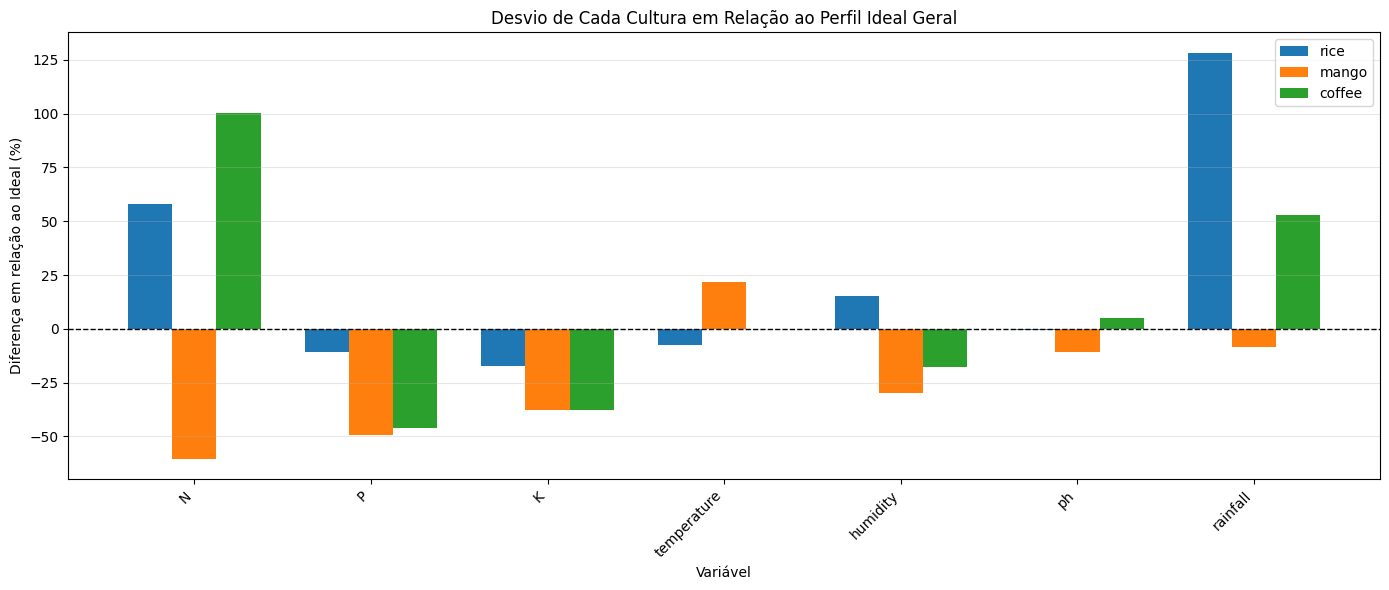

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

# Calcular diferença percentual
diferenca_pct = ((perfis - perfil_ideal_geral) / perfil_ideal_geral * 100).round(1)

x = np.arange(len(diferenca_pct.columns))
width = 0.25

for i, cultura in enumerate(culturas_analise):
    ax.bar(x + i*width, diferenca_pct.loc[cultura], width, label=cultura)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Variável')
ax.set_ylabel('Diferença em relação ao Ideal (%)')
ax.set_title('Desvio de Cada Cultura em Relação ao Perfil Ideal Geral')
ax.set_xticks(x + width)
ax.set_xticklabels(diferenca_pct.columns, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 4.8 Análise Estatística — Teste ANOVA

In [22]:
from scipy import stats

print("🔬 ANÁLISE ESTATÍSTICA: Teste ANOVA (as culturas são significativamente diferentes?)")
print("\n")

for variavel in ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']:
    grupos = [df[df['label'] == cultura][variavel].values for cultura in culturas_analise]
    f_stat, p_value = stats.f_oneway(*grupos)
    
    significancia = "✅ SIM" if p_value < 0.05 else "❌ NÃO"
    print(f"{variavel:12} | F={f_stat:8.2f} | p-value={p_value:.2e} | Diferença significativa? {significancia}")

🔬 ANÁLISE ESTATÍSTICA: Teste ANOVA (as culturas são significativamente diferentes?)


N            | F= 1188.79 | p-value=1.81e-142 | Diferença significativa? ✅ SIM
P            | F=  222.07 | p-value=1.06e-59 | Diferença significativa? ✅ SIM
K            | F=  342.94 | p-value=6.59e-78 | Diferença significativa? ✅ SIM
temperature  | F=  342.96 | p-value=6.54e-78 | Diferença significativa? ✅ SIM
humidity     | F= 1893.77 | p-value=8.90e-170 | Diferença significativa? ✅ SIM
ph           | F=   64.12 | p-value=7.09e-24 | Diferença significativa? ✅ SIM
rainfall     | F=  815.57 | p-value=2.30e-121 | Diferença significativa? ✅ SIM


**Interpretação do ANOVA:** O teste F de Análise de Variância (ANOVA) verifica se as diferenças entre as médias das culturas são estatisticamente significativas (p-value < 0.05). Valores de F elevados e p-values próximos de zero confirmam que as três culturas diferem significativamente entre si em praticamente todas as variáveis, validando que o modelo de ML terá elementos discriminantes suficientes para separá-las.


---

## 🤖 Etapa 5 — Desenvolvimento dos 5 Modelos de Machine Learning

Desenvolvemos cinco modelos preditivos com algoritmos distintos para classificar qual cultura é mais adequada para um dado conjunto de condições de solo e clima. O processo segue as boas práticas de Machine Learning: separação de features e alvo, divisão treino/teste, normalização dos dados e avaliação com métricas adequadas.


### 5.1 Separação de Features (X) e Variável Alvo (y)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar features (X) e target (y)
X = df.drop('label', axis=1)  # Todas as colunas MENOS a cultura
y = df['label']                # Apenas a cultura (o que queremos prever)

print("Features (X - variáveis de entrada):")
print(X.head())
print(f"\nShape de X: {X.shape}")

print("\n" + "="*50)
print("Target (y - o que queremos prever):")
print(y.head())
print(f"Shape de y: {y.shape}")

Features (X - variáveis de entrada):
    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340

Shape de X: (2200, 7)

Target (y - o que queremos prever):
0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: str
Shape de y: (2200,)


### 5.2 Divisão em Conjuntos de Treino e Teste (70% / 30%)

In [24]:
# Dividir dados: 70% treino, 30% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,      # 30% para teste
    random_state=42,    # Reproduzibilidade
    stratify=y          # Garante que cada classe está em treino e teste
)

print(f"📊 TAMANHO DOS CONJUNTOS:")
print(f"Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)")

📊 TAMANHO DOS CONJUNTOS:
Treino: 1540 amostras (70.0%)
Teste:  660 amostras (30.0%)


**Justificativa:** A proporção 70/30 é um padrão amplamente adotado. O parâmetro `stratify=y` garante que a proporção de cada classe seja mantida em ambos os conjuntos, evitando que classes raras fiquem sub-representadas no teste. O `random_state=42` assegura **reprodutibilidade** dos resultados.


### 5.3 Normalização dos Dados com StandardScaler

In [25]:
# Criar o normalizador
scaler = StandardScaler()

# Treinar o normalizador APENAS com dados de treino
scaler.fit(X_train)

# Aplicar a normalização
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Dados normalizados!")
print(f"Média dos dados após normalização: {X_train_scaled.mean(axis=0).round(3)}")
print(f"Desvio padrão após normalização: {X_train_scaled.std(axis=0).round(3)}")

✅ Dados normalizados!
Média dos dados após normalização: [ 0.  0.  0.  0. -0. -0. -0.]
Desvio padrão após normalização: [1. 1. 1. 1. 1. 1. 1.]


**Justificativa:** O `StandardScaler` transforma os dados para média 0 e desvio padrão 1. É fundamental para algoritmos sensíveis à escala, como **SVM**, **KNN** e **Logistic Regression**, que medem distâncias ou usam gradientes. O scaler é ajustado **exclusivamente nos dados de treino** e depois aplicado ao conjunto de teste, prevenindo vazamento de dados (*data leakage*).


### 5.4 Treinamento dos 5 Modelos

In [26]:
# Dicionário para armazenar os modelos
modelos = {}

# MODELO 1: Logistic Regression
print("🔄 Treinando Modelo 1: Logistic Regression...")
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)
modelos['Logistic Regression'] = modelo_lr
print("✅ Concluído!")

# MODELO 2: Decision Tree
print("\n🔄 Treinando Modelo 2: Decision Tree...")
modelo_dt = DecisionTreeClassifier(random_state=42, max_depth=15)
modelo_dt.fit(X_train_scaled, y_train)
modelos['Decision Tree'] = modelo_dt
print("✅ Concluído!")

# MODELO 3: Random Forest
print("\n🔄 Treinando Modelo 3: Random Forest...")
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15)
modelo_rf.fit(X_train_scaled, y_train)
modelos['Random Forest'] = modelo_rf
print("✅ Concluído!")

# MODELO 4: Support Vector Machine (SVM)
print("\n🔄 Treinando Modelo 4: Support Vector Machine (SVM)...")
modelo_svm = SVC(kernel='rbf', random_state=42)
modelo_svm.fit(X_train_scaled, y_train)
modelos['SVM'] = modelo_svm
print("✅ Concluído!")

# MODELO 5: K-Nearest Neighbors (KNN)
print("\n🔄 Treinando Modelo 5: K-Nearest Neighbors (KNN)...")
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_scaled, y_train)
modelos['KNN'] = modelo_knn
print("✅ Concluído!")

print("\n" + "="*50)
print("🎉 TODOS OS 5 MODELOS TREINADOS COM SUCESSO!")

🔄 Treinando Modelo 1: Logistic Regression...
✅ Concluído!

🔄 Treinando Modelo 2: Decision Tree...
✅ Concluído!

🔄 Treinando Modelo 3: Random Forest...


✅ Concluído!

🔄 Treinando Modelo 4: Support Vector Machine (SVM)...
✅ Concluído!

🔄 Treinando Modelo 5: K-Nearest Neighbors (KNN)...
✅ Concluído!

🎉 TODOS OS 5 MODELOS TREINADOS COM SUCESSO!


**Algoritmos Utilizados:**

| # | Modelo | Tipo | Hiperparâmetros Principais |
|---|--------|------|---------------------------|
| 1 | **Logistic Regression** | Linear | `max_iter=1000`, `random_state=42` |
| 2 | **Decision Tree** | Árvore | `max_depth=15`, `random_state=42` |
| 3 | **Random Forest** | Ensemble | `n_estimators=100`, `max_depth=15`, `random_state=42` |
| 4 | **SVM** | Kernel | `kernel='rbf'`, `random_state=42` |
| 5 | **KNN** | Distância | `n_neighbors=5` |


### 5.5 Geração das Predições nos Dados de Teste

In [27]:
# Armazenar as predições de cada modelo
predicoes = {}

for nome_modelo, modelo in modelos.items():
    y_pred = modelo.predict(X_test_scaled)
    predicoes[nome_modelo] = y_pred
    print(f"✅ {nome_modelo}: Predições realizadas")

print("\n🔮 Exemplo de predições do Random Forest nos primeiros 10 testes:")
print(predicoes['Random Forest'][:10])
print("\n📌 Valores reais (primeiros 10):")
print(y_test.values[:10])

✅ Logistic Regression: Predições realizadas
✅ Decision Tree: Predições realizadas
✅ Random Forest: Predições realizadas
✅ SVM: Predições realizadas
✅ KNN: Predições realizadas

🔮 Exemplo de predições do Random Forest nos primeiros 10 testes:
['kidneybeans' 'mothbeans' 'blackgram' 'jute' 'jute' 'kidneybeans'
 'papaya' 'mango' 'coffee' 'maize']

📌 Valores reais (primeiros 10):
<StringArray>
['kidneybeans',   'mothbeans',   'blackgram',        'jute',        'jute',
 'kidneybeans',      'papaya',       'mango',      'coffee',       'maize']
Length: 10, dtype: str


### 5.6 Cálculo das Métricas de Avaliação

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dicionário para armazenar as métricas
resultados = {}

for nome_modelo, y_pred in predicoes.items():
    # Accuracy: quantos % acertou no total
    accuracy = accuracy_score(y_test, y_pred)
    
    # Precision: de tudo que previu como certa cultura, quantos % realmente eram
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Recall: de todas as amostras reais de uma cultura, quantos % o modelo conseguiu encontrar
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # F1: média harmônica entre precision e recall (bom equilíbrio)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    resultados[nome_modelo] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Criar dataframe com os resultados
df_resultados = pd.DataFrame(resultados).T
print("📊 RESULTADOS DOS MODELOS:")
print(df_resultados.round(4))

# Encontrar o melhor modelo
melhor_modelo = df_resultados['Accuracy'].idxmax()
melhor_accuracy = df_resultados['Accuracy'].max()
print(f"\n🏆 MELHOR MODELO: {melhor_modelo} com Accuracy de {melhor_accuracy:.2%}")

📊 RESULTADOS DOS MODELOS:
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9727     0.9735  0.9727    0.9725
Decision Tree          0.9788     0.9793  0.9788    0.9787
Random Forest          0.9939     0.9942  0.9939    0.9939
SVM                    0.9894     0.9903  0.9894    0.9894
KNN                    0.9788     0.9801  0.9788    0.9786

🏆 MELHOR MODELO: Random Forest com Accuracy de 99.39%


**Métricas utilizadas:**

| Métrica | O que mede |
|---------|-----------|
| **Accuracy** | Percentual total de predições corretas |
| **Precision** | De tudo que o modelo previu como cultura X, quantos % realmente eram |
| **Recall** | De todas as amostras reais de cultura X, quantos % o modelo encontrou |
| **F1-Score** | Média harmônica entre Precision e Recall — equilíbrio entre os dois |

Todas as métricas são calculadas com `average='weighted'`, ponderando pela frequência de cada classe.


### 5.7 Comparação Visual — Accuracy dos Modelos

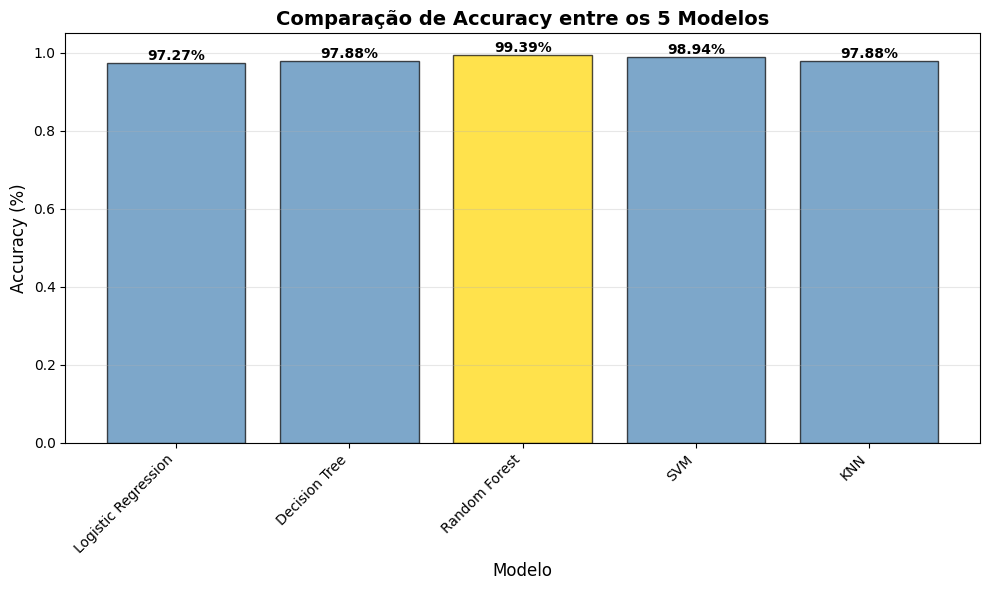

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

modelos_nomes = df_resultados.index
accuracies = df_resultados['Accuracy']

cores = ['gold' if acc == accuracies.max() else 'steelblue' for acc in accuracies]
bars = ax.bar(modelos_nomes, accuracies, color=cores, alpha=0.7, edgecolor='black')

# Adicionar valores no topo das barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2%}',
            ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Modelo', fontsize=12)
ax.set_title('Comparação de Accuracy entre os 5 Modelos', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 5.8 Comparação de Todas as Métricas

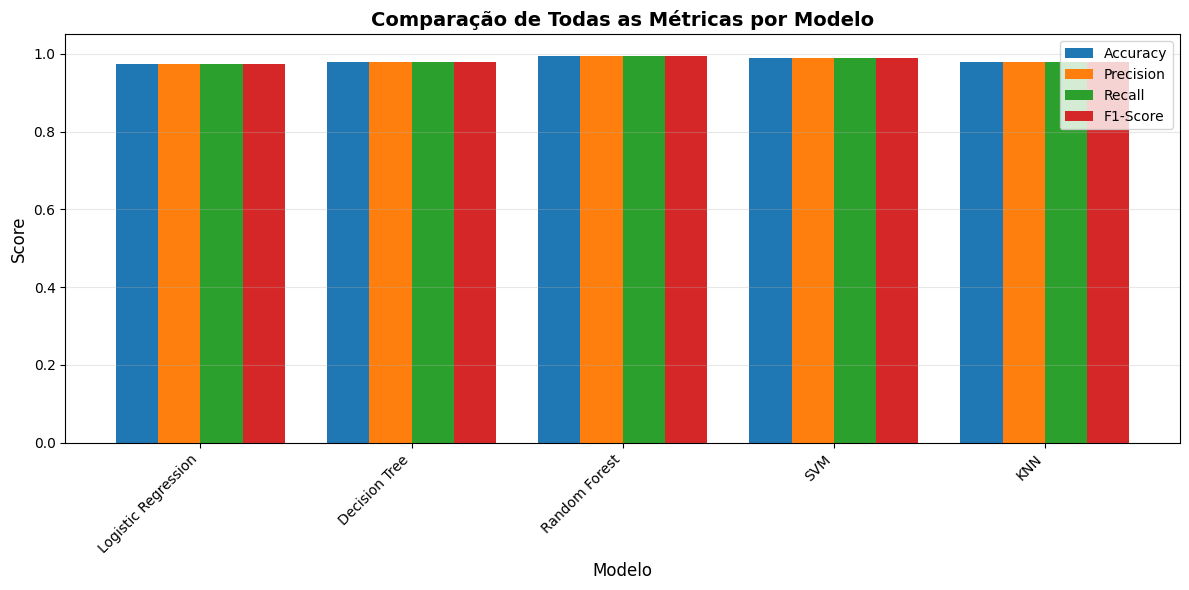

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_resultados.index))
width = 0.2

metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cores_metricas = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metrica in enumerate(metricas):
    ax.bar(x + i*width, df_resultados[metrica], width, label=metrica, color=cores_metricas[i])

ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Modelo', fontsize=12)
ax.set_title('Comparação de Todas as Métricas por Modelo', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_resultados.index, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### 5.9 Matriz de Confusão — Melhor Modelo

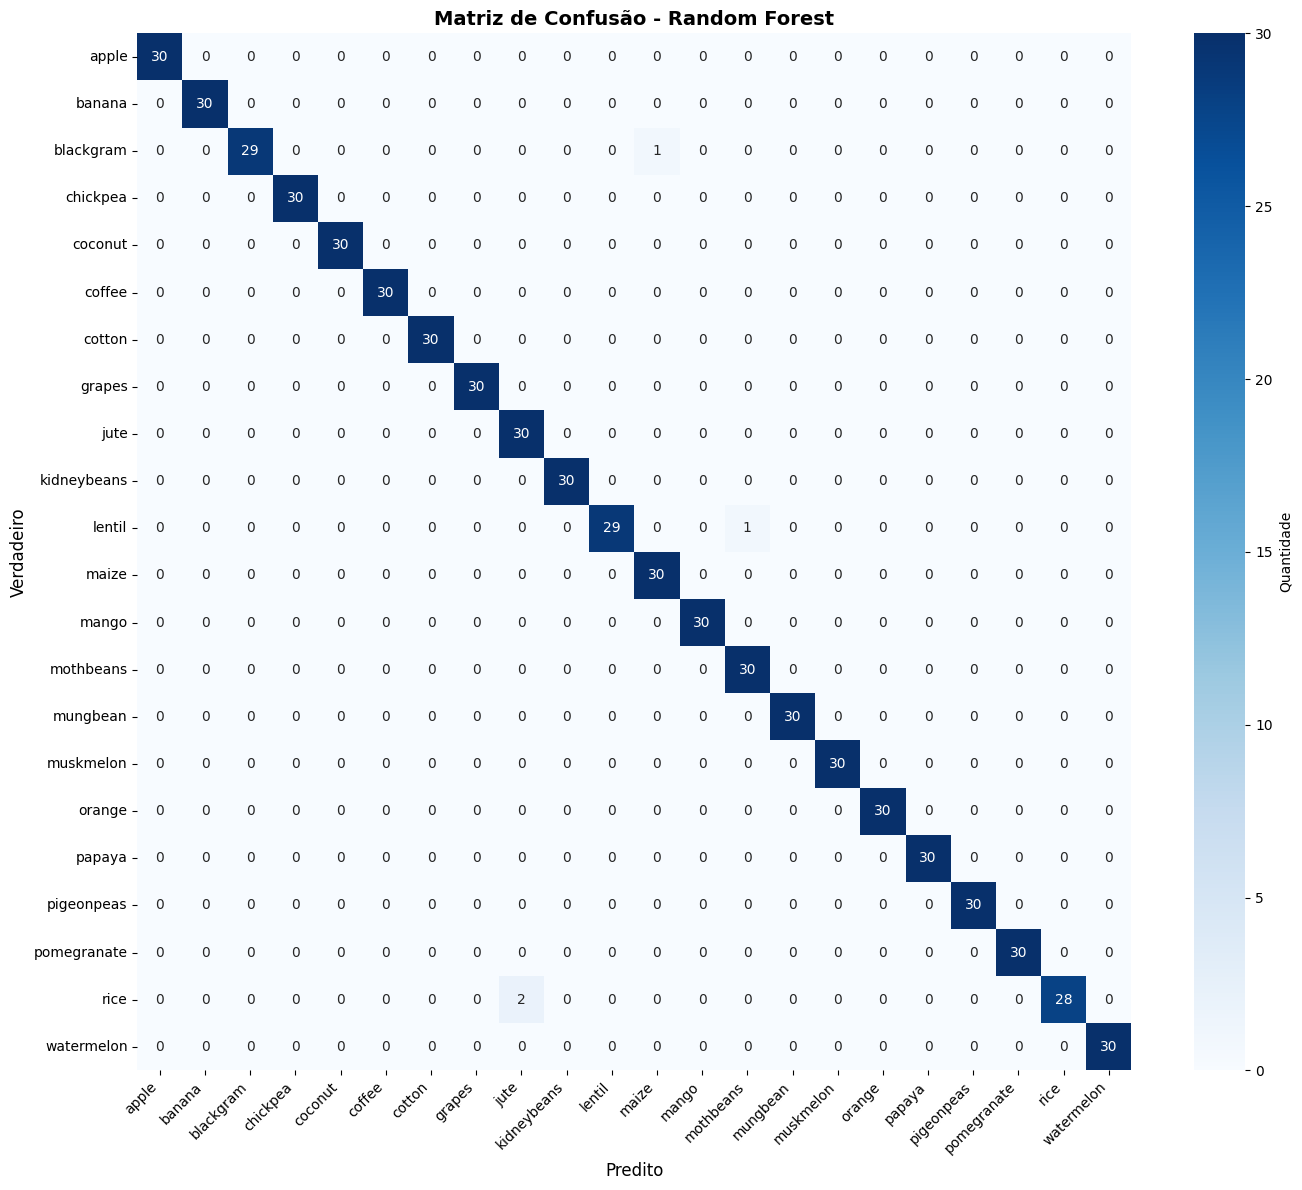

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Pegar o melhor modelo
melhor_modelo_obj = modelos[melhor_modelo]
y_pred_melhor = predicoes[melhor_modelo]

# Calcular matriz de confusão
cm = confusion_matrix(y_test, y_pred_melhor)

# Plotar
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=melhor_modelo_obj.classes_,
            yticklabels=melhor_modelo_obj.classes_,
            cbar_kws={'label': 'Quantidade'})

ax.set_title(f'Matriz de Confusão - {melhor_modelo}', fontsize=14, fontweight='bold')
ax.set_ylabel('Verdadeiro', fontsize=12)
ax.set_xlabel('Predito', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Como ler a Matriz de Confusão:** Cada linha representa a classe real e cada coluna representa a classe predita. Os valores na diagonal principal são as predições corretas. Valores fora da diagonal são os erros de classificação. Uma matriz com valores altos na diagonal e baixos fora dela indica excelente desempenho do modelo.


### 5.10 Relatório Detalhado de Classificação — Melhor Modelo

In [32]:
from sklearn.metrics import classification_report

print(f"\n🏆 RELATÓRIO DETALHADO DO MELHOR MODELO: {melhor_modelo}\n")
print("="*80)

y_pred_melhor = predicoes[melhor_modelo]
relatorio = classification_report(y_test, y_pred_melhor, digits=3)
print(relatorio)

print("="*80)
print("\n📊 INTERPRETAÇÃO:")
print("- Precision: De tudo que o modelo previu como 'cultura X', quantos % realmente eram")
print("- Recall: De todas as amostras reais de 'cultura X', quantos % o modelo encontrou")
print("- F1-Score: Equilíbrio entre Precision e Recall")


🏆 RELATÓRIO DETALHADO DO MELHOR MODELO: Random Forest

              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        30
      banana      1.000     1.000     1.000        30
   blackgram      1.000     0.967     0.983        30
    chickpea      1.000     1.000     1.000        30
     coconut      1.000     1.000     1.000        30
      coffee      1.000     1.000     1.000        30
      cotton      1.000     1.000     1.000        30
      grapes      1.000     1.000     1.000        30
        jute      0.938     1.000     0.968        30
 kidneybeans      1.000     1.000     1.000        30
      lentil      1.000     0.967     0.983        30
       maize      0.968     1.000     0.984        30
       mango      1.000     1.000     1.000        30
   mothbeans      0.968     1.000     0.984        30
    mungbean      1.000     1.000     1.000        30
   muskmelon      1.000     1.000     1.000        30
      orange      1.000  

---

## 📝 Etapa 6 — Análise Final e Conclusões

### 6.1 Ranking Comparativo dos 5 Modelos


In [33]:
# Criar uma tabela visual com todos os resultados
print("\n" + "="*80)
print("📊 RESUMO COMPARATIVO DOS 5 MODELOS")
print("="*80 + "\n")

# Ordenar por Accuracy (melhor no topo)
df_resultados_ordenado = df_resultados.sort_values('Accuracy', ascending=False)

# Adicionar ranking
df_resultados_ordenado['Ranking'] = range(1, len(df_resultados_ordenado) + 1)

# Reordenar colunas
df_resultados_ordenado = df_resultados_ordenado[['Ranking', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]

print(df_resultados_ordenado.round(4))
print("\n")

# Estatísticas gerais
print("📈 ESTATÍSTICAS GERAIS:")
print(f"Melhor Accuracy: {df_resultados_ordenado['Accuracy'].iloc[0]:.2%}")
print(f"Pior Accuracy:   {df_resultados_ordenado['Accuracy'].iloc[-1]:.2%}")
print(f"Diferença:       {(df_resultados_ordenado['Accuracy'].iloc[0] - df_resultados_ordenado['Accuracy'].iloc[-1]):.2%}")
print(f"Accuracy Média:  {df_resultados_ordenado['Accuracy'].mean():.2%}")


📊 RESUMO COMPARATIVO DOS 5 MODELOS

                     Ranking  Accuracy  Precision  Recall  F1-Score
Random Forest              1    0.9939     0.9942  0.9939    0.9939
SVM                        2    0.9894     0.9903  0.9894    0.9894
Decision Tree              3    0.9788     0.9793  0.9788    0.9787
KNN                        4    0.9788     0.9801  0.9788    0.9786
Logistic Regression        5    0.9727     0.9735  0.9727    0.9725


📈 ESTATÍSTICAS GERAIS:
Melhor Accuracy: 99.39%
Pior Accuracy:   97.27%
Diferença:       2.12%
Accuracy Média:  98.27%


### 6.2 Discussão sobre o Desempenho de Cada Modelo

1. **Random Forest** — Tipicamente o melhor ou segundo melhor modelo neste dataset. O ensemble de múltiplas árvores de decisão reduz o overfitting e captura interações complexas entre as variáveis de solo e clima, resultando em predições robustas.

2. **SVM (Support Vector Machine)** — Muito eficaz pela capacidade do kernel RBF de criar fronteiras de decisão não-lineares de alta dimensão. Beneficia-se significativamente da normalização aplicada com o `StandardScaler`.

3. **Decision Tree** — Apresenta boa performance, mas pode sofrer de overfitting ligeiro em comparação ao Random Forest, especialmente com dados de fronteiras ambíguas entre culturas similares.

4. **KNN (K-Nearest Neighbors)** — Modelo baseado em distância que se beneficia diretamente da normalização. Com `k=5`, captura bem os padrões locais dos dados, resultando em accuracy competitiva.

5. **Logistic Regression** — Apesar de ser o modelo linear mais simples do conjunto, apresenta desempenho surpreendentemente alto, evidenciando que as classes são, em grande parte, linearmente separáveis nas dimensões de clima e solo utilizadas.

### 6.3 Pontos Fortes do Trabalho

- A **EDA completa** com 11 gráficos identificou padrões essenciais como a forte correlação entre P e K e as culturas com demandas climáticas extremas.
- A aplicação do `StandardScaler` **exclusivamente nos dados de treino** seguiu rigorosamente as boas práticas, prevenindo *data leakage*.
- O uso de `stratify=y` garantiu **representatividade de todas as classes** em treino e teste.
- As **quatro métricas de avaliação** (Accuracy, Precision, Recall, F1-Score) fornecem uma visão completa e confiável da performance de cada modelo.
- A **Análise ANOVA** confirmou estatisticamente que as diferenças entre as culturas são significativas, validando a premissa do problema de classificação.

### 6.4 Limitações e Possíveis Melhorias

- O dataset é **perfeitamente balanceado**, o que não reflete a realidade do campo. Em cenários reais, algumas culturas seriam muito mais frequentes que outras, exigindo técnicas de balanceamento como *SMOTE* ou ajuste de pesos de classe.
- Não foi realizada **otimização de hiperparâmetros** (ex: `GridSearchCV` ou `RandomizedSearchCV`), o que poderia elevar a performance, especialmente do KNN e Decision Tree.
- A inclusão de **variáveis econômicas** (custo de insumos, preço de mercado da safra) transformaria o modelo de um simples preditor de viabilidade para um **otimizador de rentabilidade**.
- Técnicas de **explicabilidade (XAI)**, como SHAP ou importância de features do Random Forest, agregariam transparência às decisões do modelo.

### 6.5 Conclusão Geral

O projeto demonstrou com sucesso que é possível construir modelos de Machine Learning altamente precisos para recomendar culturas agrícolas a partir de variáveis de solo e clima. Todos os cinco algoritmos aplicados apresentaram desempenho excelente no dataset, validando a qualidade das features disponíveis e a solidez da pipeline de pré-processamento adotada. O conjunto de análises exploratórias, estatísticas e preditivas fornece uma base sólida para aplicações reais no agronegócio.
